In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import os

## 1. Data Import & Cleaning

In [2]:
raw_data = pd.read_csv('neso - demanddata_2025.csv')
raw_data['SETTLEMENT_DATE'] = pd.to_datetime(raw_data['SETTLEMENT_DATE'])
raw_data.head()

,SETTLEMENT_DATE,SETTLEMENT_PERIOD,ND,TSD,ENGLAND_WALES_DEMAND,EMBEDDED_WIND_GENERATION,EMBEDDED_WIND_CAPACITY,EMBEDDED_SOLAR_GENERATION,EMBEDDED_SOLAR_CAPACITY,NON_BM_STOR,...,IFA_FLOW,IFA2_FLOW,BRITNED_FLOW,MOYLE_FLOW,EAST_WEST_FLOW,NEMO_FLOW,NSL_FLOW,ELECLINK_FLOW,VIKING_FLOW,GREENLINK_FLOW
0,2025-01-01,1,21036,26215,19918,5405,6606,0,19270,0,...,-1518,-1026,1,-232,-386,-558,96,0,241,0
1,2025-01-01,2,21222,26063,20167,5358,6606,0,19270,0,...,-1513,-1023,1,-124,-282,-564,51,0,262,0
2,2025-01-01,3,21385,25734,20328,5237,6606,0,19270,0,...,-1428,-922,1,-119,-384,-205,62,0,414,0
3,2025-01-01,4,20473,24988,19460,5115,6606,0,19270,0,...,-1423,-915,0,-119,-334,-193,37,0,423,0
4,2025-01-01,5,19634,24912,18654,5080,6606,0,19270,0,...,-1539,-899,0,-119,-363,-622,-282,0,288,0


In [3]:
raw_data[raw_data['SETTLEMENT_PERIOD']==49]

,SETTLEMENT_DATE,SETTLEMENT_PERIOD,ND,TSD,ENGLAND_WALES_DEMAND,EMBEDDED_WIND_GENERATION,EMBEDDED_WIND_CAPACITY,EMBEDDED_SOLAR_GENERATION,EMBEDDED_SOLAR_CAPACITY,NON_BM_STOR,...,IFA_FLOW,IFA2_FLOW,BRITNED_FLOW,MOYLE_FLOW,EAST_WEST_FLOW,NEMO_FLOW,NSL_FLOW,ELECLINK_FLOW,VIKING_FLOW,GREENLINK_FLOW
14350,2025-10-26,49,20699,24402,19265,4686,6606,0,21649,0,...,-373,-230,-273,-85,-82,288,-393,209,-601,63


In [4]:
raw_data['helper_column_offset'] = pd.to_timedelta((raw_data['SETTLEMENT_PERIOD']-1)*30, unit = 'm')
raw_data['settlement_period_start'] = raw_data['SETTLEMENT_DATE'] + raw_data['helper_column_offset']
raw_data['day_off_week'] = raw_data['settlement_period_start'].dt.dayofweek

In [5]:
raw_data.head()

,SETTLEMENT_DATE,SETTLEMENT_PERIOD,ND,TSD,ENGLAND_WALES_DEMAND,EMBEDDED_WIND_GENERATION,EMBEDDED_WIND_CAPACITY,EMBEDDED_SOLAR_GENERATION,EMBEDDED_SOLAR_CAPACITY,NON_BM_STOR,...,MOYLE_FLOW,EAST_WEST_FLOW,NEMO_FLOW,NSL_FLOW,ELECLINK_FLOW,VIKING_FLOW,GREENLINK_FLOW,helper_column_offset,settlement_period_start,day_off_week
0,2025-01-01,1,21036,26215,19918,5405,6606,0,19270,0,...,-232,-386,-558,96,0,241,0,0 days 00:00:00,2025-01-01 00:00:00,2
1,2025-01-01,2,21222,26063,20167,5358,6606,0,19270,0,...,-124,-282,-564,51,0,262,0,0 days 00:30:00,2025-01-01 00:30:00,2
2,2025-01-01,3,21385,25734,20328,5237,6606,0,19270,0,...,-119,-384,-205,62,0,414,0,0 days 01:00:00,2025-01-01 01:00:00,2
3,2025-01-01,4,20473,24988,19460,5115,6606,0,19270,0,...,-119,-334,-193,37,0,423,0,0 days 01:30:00,2025-01-01 01:30:00,2
4,2025-01-01,5,19634,24912,18654,5080,6606,0,19270,0,...,-119,-363,-622,-282,0,288,0,0 days 02:00:00,2025-01-01 02:00:00,2


In [6]:
# Create clean dataframe
electricity_demand = pd.DataFrame()
electricity_demand['settlement_period_start'] = raw_data['settlement_period_start']
electricity_demand['total_national_demand'] = raw_data['ND'] + raw_data['EMBEDDED_WIND_GENERATION'] + raw_data['EMBEDDED_SOLAR_GENERATION']
electricity_demand['total_national_demand'] = electricity_demand['total_national_demand'] / 1000
electricity_demand['day_of_week'] = electricity_demand['settlement_period_start'].dt.dayofweek
electricity_demand['day'] = electricity_demand['settlement_period_start'].dt.day_name()
electricity_demand['settlement_period'] = raw_data['SETTLEMENT_PERIOD']
electricity_demand['is_weekend'] = electricity_demand['day_of_week']>4

In [7]:
electricity_demand.head()

,settlement_period_start,total_national_demand,day_of_week,day,settlement_period,is_weekend
0,2025-01-01 00:00:00,26.441,2,Wednesday,1,False
1,2025-01-01 00:30:00,26.580,2,Wednesday,2,False
2,2025-01-01 01:00:00,26.622,2,Wednesday,3,False
3,2025-01-01 01:30:00,25.588,2,Wednesday,4,False
4,2025-01-01 02:00:00,24.714,2,Wednesday,5,False


## 2. Data Analysis

### 2a. Electricity demand curve

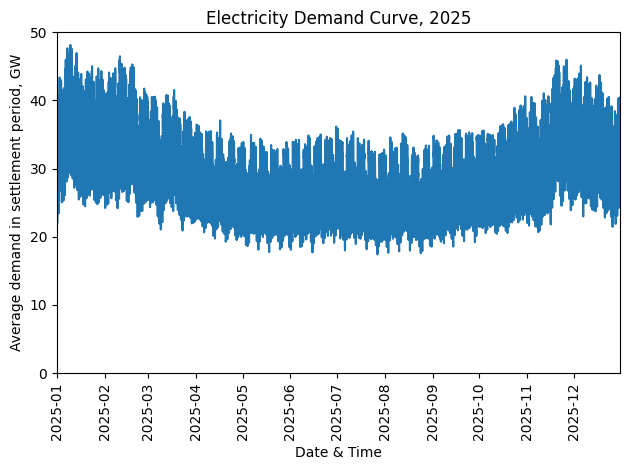

In [8]:
# Electricity demand curve generation
plt.plot(electricity_demand['settlement_period_start'], electricity_demand['total_national_demand'])
plt.xlabel("Date & Time")
plt.ylabel("Average demand in settlement period, GW")
plt.title("Electricity Demand Curve, 2025")
plt.ylim(0, 50)
plt.xlim(pd.to_datetime('2025-1-1'), pd.to_datetime('2025-12-31'))
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig(r'images\2025_electricity_demand_curve.png')
plt.show()

### 2b. Peak demand

In [9]:
# Determine peak demand
peak_demand = electricity_demand['total_national_demand'].max()
peak_demand

48.141

In [10]:
peak_time = electricity_demand.loc[electricity_demand['total_national_demand'] == peak_demand].iloc[0,0]
peak_time

Timestamp('2025-01-09 17:00:00')

### 2c. Electricity demand curve with peak demand stamp

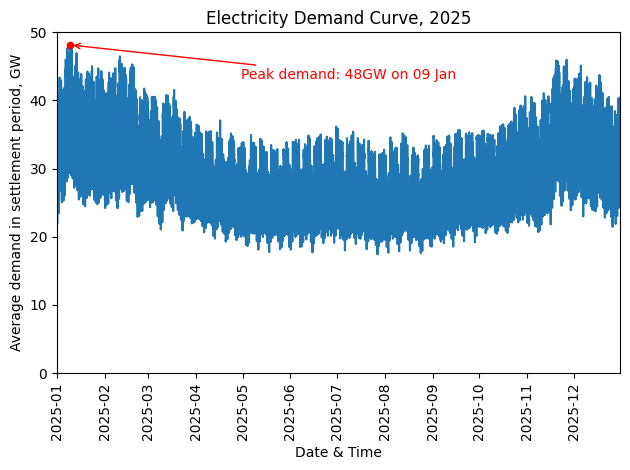

In [11]:
# Electricity demand curve with time stamp
plt.plot(electricity_demand['settlement_period_start'], electricity_demand['total_national_demand'])
plt.xlabel("Date & Time")
plt.ylabel("Average demand in settlement period, GW")
plt.title("Electricity Demand Curve, 2025")
plt.ylim(0, 50)
plt.xlim(pd.to_datetime('2025-1-1'), pd.to_datetime('2025-12-31'))
plt.xticks(rotation=90)

plt.scatter(peak_time, peak_demand, color='red', s=20, zorder=5)
plt.annotate(
    f"Peak demand: {int(peak_demand)}GW on {peak_time.strftime("%d %b")}",
    xy=(peak_time, peak_demand),            # point to annotate
    xytext=(peak_time + pd.Timedelta(days = 180), peak_demand-5), # text position slightly above
    arrowprops=dict(arrowstyle="->", color="red"),
    ha="center",
    color="red",
    fontsize=10
)

plt.tight_layout()
plt.savefig(r'images\2025_electricity_demand_curve_with_peak.png')

plt.show()

### 2d. Load duration curve

In [12]:
electricity_demand["load_duration_curve"] = electricity_demand["total_national_demand"].sort_values(ascending=False).values
electricity_demand.tail()

,settlement_period_start,total_national_demand,day_of_week,day,settlement_period,is_weekend,load_duration_curve
17515,2025-12-31 21:30:00,32.627,2,Wednesday,44,False,17.661
17516,2025-12-31 22:00:00,31.408,2,Wednesday,45,False,17.655
17517,2025-12-31 22:30:00,30.622,2,Wednesday,46,False,17.612
17518,2025-12-31 23:00:00,29.596,2,Wednesday,47,False,17.580
17519,2025-12-31 23:30:00,28.901,2,Wednesday,48,False,17.416


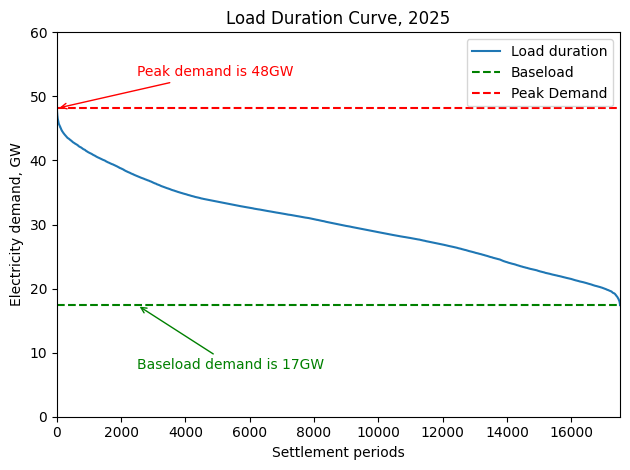

In [13]:
plt.plot(
    electricity_demand.index, 
    electricity_demand["load_duration_curve"],
    label = "Load duration")
plt.xlabel("Settlement periods")
plt.ylabel("Electricity demand, GW")
plt.title("Load Duration Curve, 2025")
plt.ylim(0, (electricity_demand['total_national_demand'].max()+15) //10*10)
plt.xlim(0,17519)
plt.axhline(
    y = electricity_demand['load_duration_curve'].min(),
    color = "green",
    linestyle = "--",
    label = "Baseload"
)
plt.annotate(
    f"Baseload demand is {int(electricity_demand['load_duration_curve'].min())}GW",
    xy = (2500, electricity_demand['load_duration_curve'].min()),
    xytext=(2500, (electricity_demand['load_duration_curve'].min() - 10)),
    color = "green",
    arrowprops=dict(arrowstyle="->", color="green")
)
plt.annotate(
    f"Peak demand is {int(electricity_demand['load_duration_curve'].max())}GW",
    xy=(0, electricity_demand['load_duration_curve'].max()),
    xytext = (2500, (electricity_demand['load_duration_curve'].max()+5) ),
    color="red",
    arrowprops = dict(arrowstyle="->", color="red")
)
plt.axhline(
    y = electricity_demand['load_duration_curve'].max(),
    color="red",
    linestyle="--",
    label = "Peak Demand"
)
plt.legend()

plt.tight_layout()
plt.savefig(r'images\2025_load_duration_curve.png')

plt.show()

### 2e. Peak demand by month

In [14]:
electricity_demand.head()

,settlement_period_start,total_national_demand,day_of_week,day,settlement_period,is_weekend,load_duration_curve
0,2025-01-01 00:00:00,26.441,2,Wednesday,1,False,48.141
1,2025-01-01 00:30:00,26.580,2,Wednesday,2,False,48.093
2,2025-01-01 01:00:00,26.622,2,Wednesday,3,False,47.659
3,2025-01-01 01:30:00,25.588,2,Wednesday,4,False,47.657
4,2025-01-01 02:00:00,24.714,2,Wednesday,5,False,47.644


In [15]:
peak_m_demand = pd.DataFrame()
peak_m_demand['month'] = [f"2025-{month}-15" for month in range(1,13)]
peak_m_demand['month'] = pd.to_datetime(peak_m_demand['month'])

peak_values = []

for month in range(1,13):

    start = f'2025-{month}-01 00:00:00'

    if start == '2025-12-01 00:00:00':
        end = '2026-01-01 00:00:00'
    else:
        end = f'2025-{month+1}-01 00:00:00'

    mask = (
        (electricity_demand['settlement_period_start']>=start) &
        (electricity_demand['settlement_period_start']<end)
    )
    peak_value = electricity_demand[mask]
    peak_values.append(peak_value['total_national_demand'].max())

peak_m_demand['monthly peak'] = peak_values
peak_m_demand

,month,monthly peak
0,2025-01-15,48.141
1,2025-02-15,46.488
2,2025-03-15,41.544
3,2025-04-15,37.080
4,2025-05-15,34.952
5,2025-06-15,36.172
6,2025-07-15,35.859
7,2025-08-15,35.177
8,2025-09-15,35.662
9,2025-10-15,40.617


[]

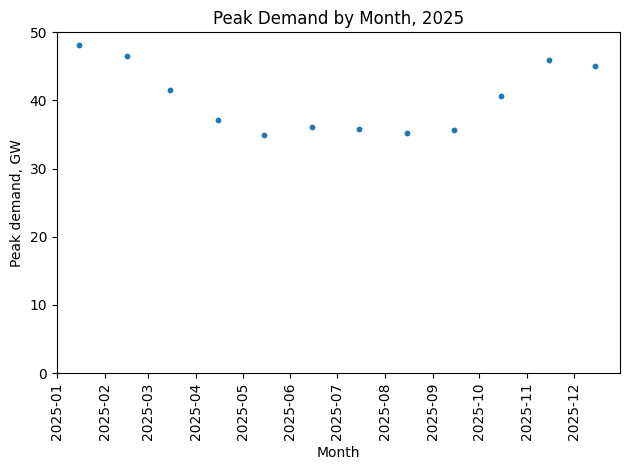

In [16]:
plt.scatter(peak_m_demand['month'], peak_m_demand['monthly peak'], s=10)
plt.ylabel("Peak demand, GW")
plt.xlabel("Month")
plt.title("Peak Demand by Month, 2025")
plt.ylim(0, 50)
plt.xlim(pd.to_datetime('2025-1-1'), pd.to_datetime('2025-12-31'))
plt.xticks(
#    ticks = peak_m_demand['month'],
#    label = peak_m_demand['month'].dt.strftime('%Y-%m'),
    rotation = 90
)
plt.tight_layout()
plt.plot()

### 2g. Peak demand by week

In [17]:
peak_w_demand = pd.DataFrame()

weeks = []
date = datetime(2025,1,1)
while date < datetime(2026,1,1):
    weeks.append(date)
    date = date + timedelta(days=7)

peak_w_demand['week'] = weeks

peak_values = []
for date in peak_w_demand['week']:
    start = date
    end = date + timedelta(days=6)
    if end >= datetime(2026,1,1):
        end = datetime(2025,12,31)

    
    mask = (
        (electricity_demand['settlement_period_start']>=start) &
        (electricity_demand['settlement_period_start']<=end)
    )

    peak_value = electricity_demand[mask]
    peak_values.append(int(peak_value['total_national_demand'].max()))
    
peak_w_demand['weekly peak'] = peak_values
peak_w_demand

,week,weekly peak
0,2025-01-01,45
1,2025-01-08,48
2,2025-01-15,44
3,2025-01-22,45
4,2025-01-29,44
5,2025-02-05,46
6,2025-02-12,44
7,2025-02-19,44
8,2025-02-26,41
9,2025-03-05,40


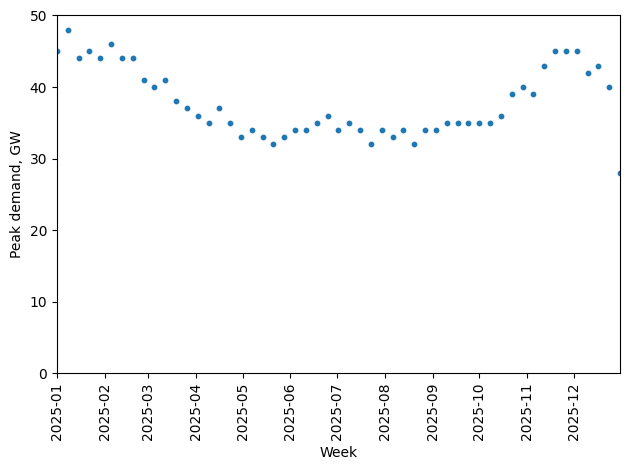

In [18]:
plt.scatter(peak_w_demand['week'], peak_w_demand['weekly peak'], s=10 )
plt.xlabel('Week')
plt.ylabel('Peak demand, GW')
plt.ylim(0, 50)
plt.xlim(pd.to_datetime('2025-1-1'), pd.to_datetime('2025-12-31'))
plt.xticks(rotation = 90)
plt.tight_layout()
plt.show()

### 2f. Selected winter vs summer week

In [19]:
summer_week = pd.DataFrame()
summer_week_start = '2025-7-7'
summer_week_end = '2025-7-14'

mask = (
    (electricity_demand['settlement_period_start'] >= summer_week_start) &
    (electricity_demand['settlement_period_start'] < summer_week_end)
)

summer_week = electricity_demand[mask]
summer_week['adjusted_period'] = summer_week['settlement_period_start'] - pd.Timestamp(summer_week_start)

In [20]:
winter_week = pd.DataFrame()
winter_week_start = '2025-2-3'
winter_week_end = '2025-2-10'

mask = (
    (electricity_demand['settlement_period_start'] >= winter_week_start)
    &
    (electricity_demand['settlement_period_start'] < winter_week_end)
)

winter_week = electricity_demand[mask]
winter_week['adjusted_period'] = winter_week['settlement_period_start'] - pd.Timestamp(winter_week_start)

[]

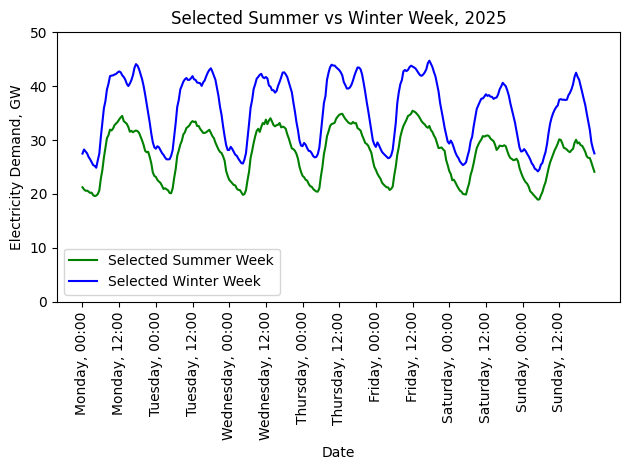

In [21]:
plt.plot(summer_week['adjusted_period'], summer_week['total_national_demand'], color='green', label='Selected Summer Week')
plt.plot(winter_week['adjusted_period'], winter_week['total_national_demand'], color='blue', label='Selected Winter Week')
plt.xlabel('Date')
plt.ylabel('Electricity Demand, GW')
plt.ylim(0,50)
plt.title('Selected Summer vs Winter Week, 2025')

timestamps_for_ticks = [pd.Timedelta(hours=i*12) for i in range(0,14)]
numeric_ticks = [i.view('int64') for i in timestamps_for_ticks]
tick_labels = [
    f"Day {i//2 + 1} {'00:00' if i % 2 == 0 else '12:00'}"
    for i in range(0,14)
]
tick_days = ['Monday, 00:00', 'Monday, 12:00', 'Tuesday, 00:00', 'Tuesday, 12:00', 'Wednesday, 00:00', 'Wednesday, 12:00',
            'Thursday, 00:00', 'Thursday, 12:00', 'Friday, 00:00', 'Friday, 12:00', 
            'Saturday, 00:00', 'Saturday, 12:00', 'Sunday, 00:00', 'Sunday, 12:00']
plt.xticks(ticks=numeric_ticks, labels = tick_days, rotation = 90)

plt.legend()
plt.tight_layout()
plt.plot()

### 2g. Average daily demands

In [22]:
electricity_demand.head()

,settlement_period_start,total_national_demand,day_of_week,day,settlement_period,is_weekend,load_duration_curve
0,2025-01-01 00:00:00,26.441,2,Wednesday,1,False,48.141
1,2025-01-01 00:30:00,26.580,2,Wednesday,2,False,48.093
2,2025-01-01 01:00:00,26.622,2,Wednesday,3,False,47.659
3,2025-01-01 01:30:00,25.588,2,Wednesday,4,False,47.657
4,2025-01-01 02:00:00,24.714,2,Wednesday,5,False,47.644


In [23]:
# Average daily profile
avg_daily_profile = (
    electricity_demand
        .groupby('settlement_period')[['total_national_demand']]
        .mean()
)
avg_daily_profile = avg_daily_profile[avg_daily_profile.index <= 48]
avg_daily_profile['time_of_day'] = [pd.Timedelta(minutes=(i-1)*30) for i in avg_daily_profile.index]


# Average weekday profile
avg_weekday_profile = (
    electricity_demand[electricity_demand['is_weekend']==False]
        .groupby('settlement_period')[['total_national_demand']]
        .mean()
)
avg_weekday_profile = avg_weekday_profile[avg_weekday_profile.index <= 48]
avg_weekday_profile['time_of_day'] = [pd.Timedelta(minutes=(i-1)*30) for i in avg_weekday_profile.index]


# Average weekend profile
avg_weekend_profile = (
    electricity_demand[electricity_demand['is_weekend']==True]
        .groupby('settlement_period')[['total_national_demand']]
        .mean()
)
avg_weekend_profile = avg_weekend_profile[avg_weekend_profile.index <= 48]
avg_weekend_profile['time_of_day'] = [pd.Timedelta(minutes=(i-1)*30) for i in avg_weekend_profile.index]

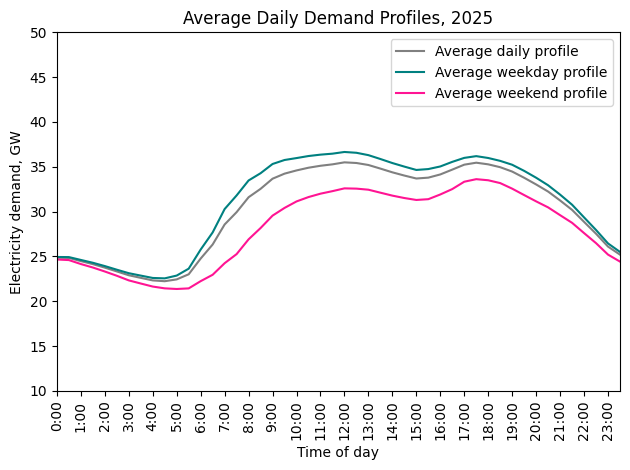

In [24]:
plt.plot(avg_daily_profile['time_of_day'], avg_daily_profile['total_national_demand'], color='gray', label = 'Average daily profile')
plt.plot(avg_weekday_profile['time_of_day'], avg_weekday_profile['total_national_demand'], color='teal', label = 'Average weekday profile')
plt.plot(avg_weekend_profile['time_of_day'], avg_weekend_profile['total_national_demand'], color='deeppink', label = 'Average weekend profile')
plt.xlabel('Time of day')
plt.ylabel('Electricity demand, GW')
plt.title('Average Daily Demand Profiles, 2025')
plt.ylim(10, 50)
plt.xlim(
    pd.Timedelta(hours=0).view('int64'), 
    pd.Timedelta(hours=23.5).view('int64')
)
plt.legend()

timedelta_ticks = [pd.Timedelta(hours=hour) for hour in range(0,24)]
numeric_ticks = [tick.view('int64') for tick in timedelta_ticks]
tick_labels = [f'{hour}:00' for hour in range(0,24)]
plt.xticks(
    ticks = numeric_ticks,
    labels = tick_labels,
    rotation = 90
)

plt.tight_layout()
plt.savefig(r"images\2025_avg_daily_demands.png")

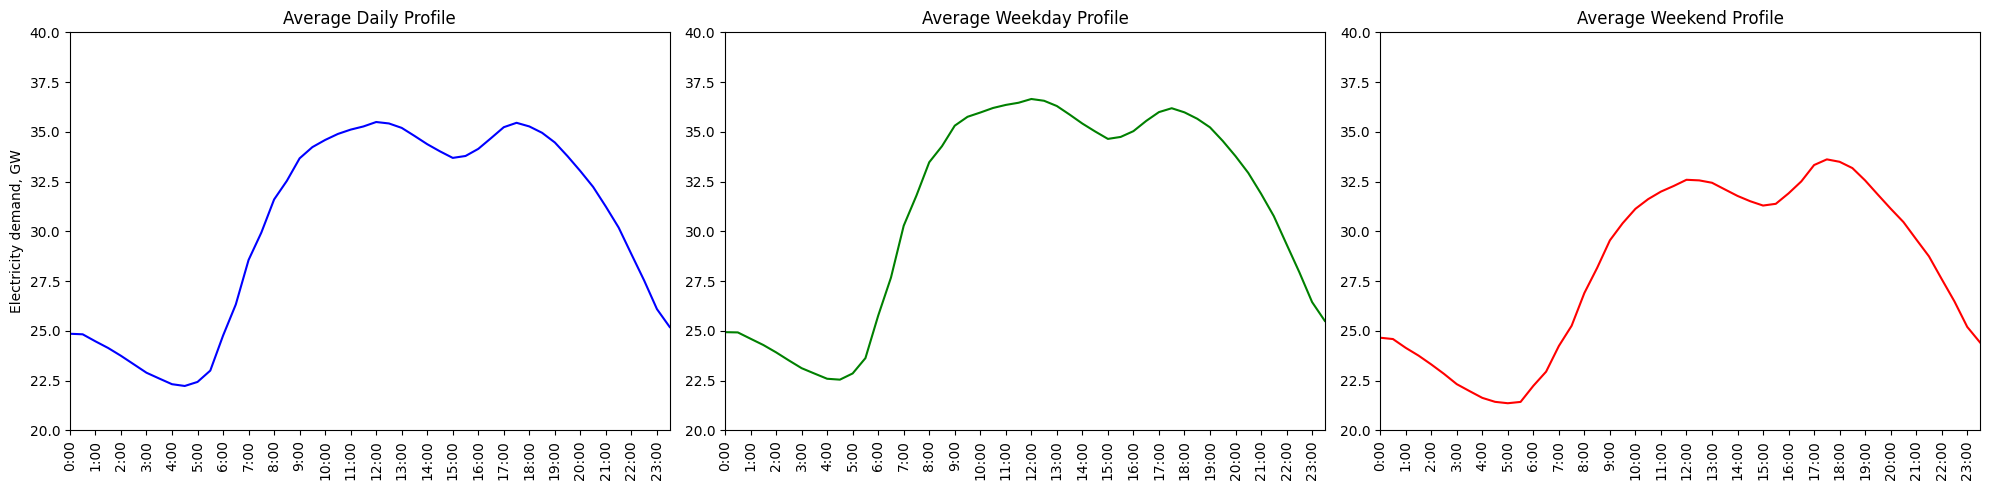

In [25]:
fig, axes = plt.subplots(ncols=3, figsize=(20,5))
axes[0].plot(avg_daily_profile['time_of_day'], avg_daily_profile['total_national_demand'], color='blue')
axes[0].set_ylim(20,40)
axes[0].set_xlim(
    pd.Timedelta(hours=0).view('int64'), 
    pd.Timedelta(hours=23.5).view('int64')
)
axes[0].set_xticks(numeric_ticks)
axes[0].set_xticklabels(tick_labels, rotation=90)
axes[0].set_ylabel('Electricity demand, GW')
axes[0].set_title('Average Daily Profile')

axes[1].plot(avg_weekday_profile['time_of_day'], avg_weekday_profile['total_national_demand'], color='green')
axes[1].set_ylim(20,40)
axes[1].set_xlim(
    pd.Timedelta(hours=0).view('int64'), 
    pd.Timedelta(hours=23.5).view('int64')
)
axes[1].set_xticks(numeric_ticks)
axes[1].set_xticklabels(tick_labels, rotation=90)
axes[1].set_title('Average Weekday Profile')

axes[2].plot(avg_weekend_profile['time_of_day'], avg_weekend_profile['total_national_demand'], color='red')
axes[2].set_ylim(20,40)
axes[2].set_xlim(
    pd.Timedelta(hours=0).view('int64'), 
    pd.Timedelta(hours=23.5).view('int64')
)
axes[2].set_xticks(numeric_ticks)
axes[2].set_xticklabels(tick_labels, rotation=90)
axes[2].set_title('Average Weekend Profile')

plt.tight_layout()
plt.savefig(r"images\2025_avg_daily_demands2.png")

### 2h. Average daily profile by season
- Winter - December, January, February
- Spring - March, April, May
- Summer - June, July, August
- Autumn - September, October, November

In [26]:
electricity_demand.head()

,settlement_period_start,total_national_demand,day_of_week,day,settlement_period,is_weekend,load_duration_curve
0,2025-01-01 00:00:00,26.441,2,Wednesday,1,False,48.141
1,2025-01-01 00:30:00,26.580,2,Wednesday,2,False,48.093
2,2025-01-01 01:00:00,26.622,2,Wednesday,3,False,47.659
3,2025-01-01 01:30:00,25.588,2,Wednesday,4,False,47.657
4,2025-01-01 02:00:00,24.714,2,Wednesday,5,False,47.644


In [27]:
electricity_demand['season'] = ''
# Winter
winter_mask = (
    (electricity_demand['settlement_period_start'].dt.month == 12) |
    (electricity_demand['settlement_period_start'].dt.month <= 2)
)
electricity_demand.loc[winter_mask,'season'] = 'Winter'
avg_winter_profile = (
    electricity_demand[winter_mask]
        .groupby('settlement_period')[['total_national_demand']]
        .mean()
)
avg_winter_profile = avg_winter_profile[avg_winter_profile.index <= 48 ]

# Spring
spring_mask = (
    (electricity_demand['settlement_period_start'].dt.month > 2) &
    (electricity_demand['settlement_period_start'].dt.month <= 5)
)
electricity_demand.loc[spring_mask,'season'] = 'Spring'
avg_spring_profile = (
    electricity_demand[spring_mask]
        .groupby('settlement_period')[['total_national_demand']]
        .mean()
)
avg_spring_profile = avg_spring_profile[avg_spring_profile.index <= 48 ]

# Summer
summer_mask = (
    (electricity_demand['settlement_period_start'].dt.month > 5) &
    (electricity_demand['settlement_period_start'].dt.month <= 8)
)
electricity_demand.loc[summer_mask,'season'] = 'Summer'
avg_summer_profile = (
    electricity_demand[summer_mask]
        .groupby('settlement_period')[['total_national_demand']]
        .mean()
)
avg_summer_profile = avg_summer_profile[avg_summer_profile.index <= 48 ]

# Autumn
autumn_mask = (
    (electricity_demand['settlement_period_start'].dt.month > 8) &
    (electricity_demand['settlement_period_start'].dt.month <= 11)
)
electricity_demand.loc[autumn_mask,'season'] = 'Autumn'
avg_autumn_profile = (
    electricity_demand[autumn_mask]
        .groupby('settlement_period')[['total_national_demand']]
        .mean()
)
avg_autumn_profile = avg_autumn_profile[avg_autumn_profile.index <= 48 ]

In [28]:
electricity_demand[spring_mask]

,settlement_period_start,total_national_demand,day_of_week,day,settlement_period,is_weekend,load_duration_curve,season
2832,2025-03-01 00:00:00,28.208,5,Saturday,1,True,36.891,Spring
2833,2025-03-01 00:30:00,28.847,5,Saturday,2,True,36.890,Spring
2834,2025-03-01 01:00:00,28.373,5,Saturday,3,True,36.888,Spring
2835,2025-03-01 01:30:00,27.745,5,Saturday,4,True,36.887,Spring
2836,2025-03-01 02:00:00,27.275,5,Saturday,5,True,36.884,Spring
...,...,...,...,...,...,...,...,...
7241,2025-05-31 21:30:00,25.553,5,Saturday,44,True,31.521,Spring
7242,2025-05-31 22:00:00,24.947,5,Saturday,45,True,31.520,Spring
7243,2025-05-31 22:30:00,24.036,5,Saturday,46,True,31.520,Spring
7244,2025-05-31 23:00:00,22.760,5,Saturday,47,True,31.519,Spring


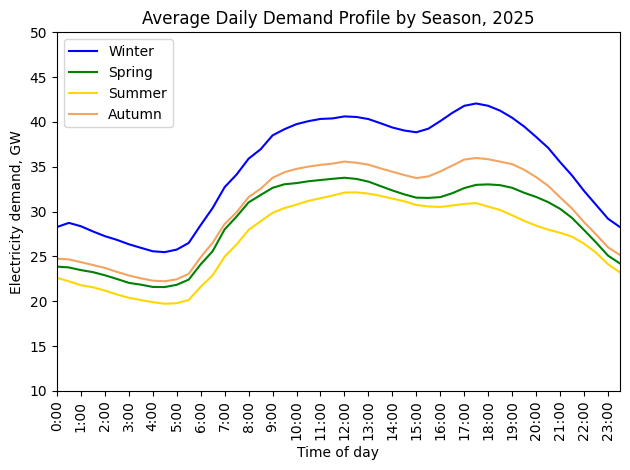

In [29]:
avg_winter_profile['time_of_day'] = [pd.Timedelta(minutes=(i-1)*30) for i in avg_weekend_profile.index]

plt.plot(avg_winter_profile['time_of_day'], avg_winter_profile['total_national_demand'], color='blue', label='Winter')
plt.plot(avg_winter_profile['time_of_day'], avg_spring_profile['total_national_demand'], color='green', label='Spring')
plt.plot(avg_winter_profile['time_of_day'], avg_summer_profile['total_national_demand'], color='gold', label='Summer')
plt.plot(avg_winter_profile['time_of_day'], avg_autumn_profile['total_national_demand'], color='sandybrown', label='Autumn')
plt.title('Average Daily Demand Profile by Season, 2025')
plt.xlabel('Time of day')
plt.ylabel('Electricity demand, GW')
plt.ylim(10, 50)
plt.xlim(
    pd.Timedelta(hours=0).view('int64'), 
    pd.Timedelta(hours=23.5).view('int64')
)
plt.legend()

timedelta_ticks = [pd.Timedelta(hours=hour) for hour in range(0,24)]
numeric_ticks = [tick.view('int64') for tick in timedelta_ticks]
tick_labels = [f'{hour}:00' for hour in range(0,24)]
plt.xticks(
    ticks = numeric_ticks,
    labels = tick_labels,
    rotation = 90
)
plt.legend()
plt.tight_layout()
plt.savefig(r"images\2025_avg_daily_seasonal_demands.png")

## 3. Statistical Analysis

Each day contains 48 settlement periods --> 
- A daily moving average will be over 48 periods
- A weekly moving average will be over 7x48=336 periods
- A monthly moving average will be over 30*48=1440 periods

### 3a. Daily Moving Average

[]

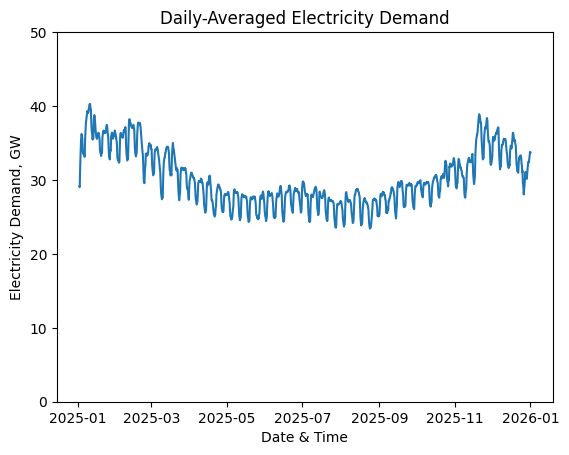

In [30]:
electricity_demand['MA_daily'] = electricity_demand['total_national_demand'].rolling(window=48).mean()
plt.plot(electricity_demand['settlement_period_start'], electricity_demand['MA_daily'])
plt.xlabel('Date & Time')
plt.ylabel('Electricity Demand, GW')
plt.ylim(0,50)
plt.title('Daily-Averaged Electricity Demand')
plt.plot()

### 3b. Weekly Moving Average

Text(0.5, 1.0, 'Weekly-Average Electricity Demand')

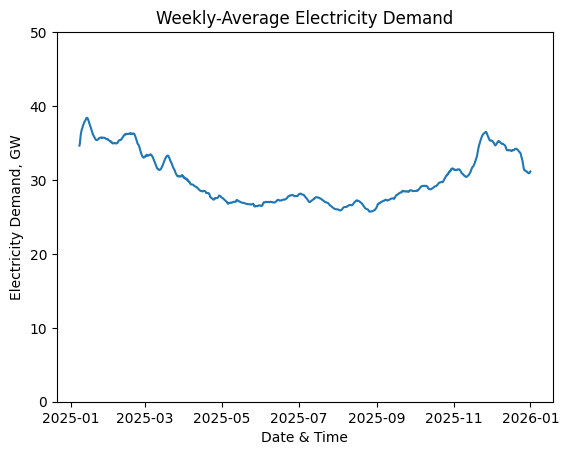

In [31]:
electricity_demand['MA_weekly'] = electricity_demand['total_national_demand'].rolling(window=336).mean()
plt.plot(electricity_demand['settlement_period_start'], electricity_demand['MA_weekly'])
plt.xlabel('Date & Time')
plt.ylabel('Electricity Demand, GW')
plt.ylim(0,50)
plt.title('Weekly-Average Electricity Demand')

### 3c. Moving average comparison

In [32]:
electricity_demand['MA_monthly'] = electricity_demand['total_national_demand'].rolling(window=1440).mean()

[]

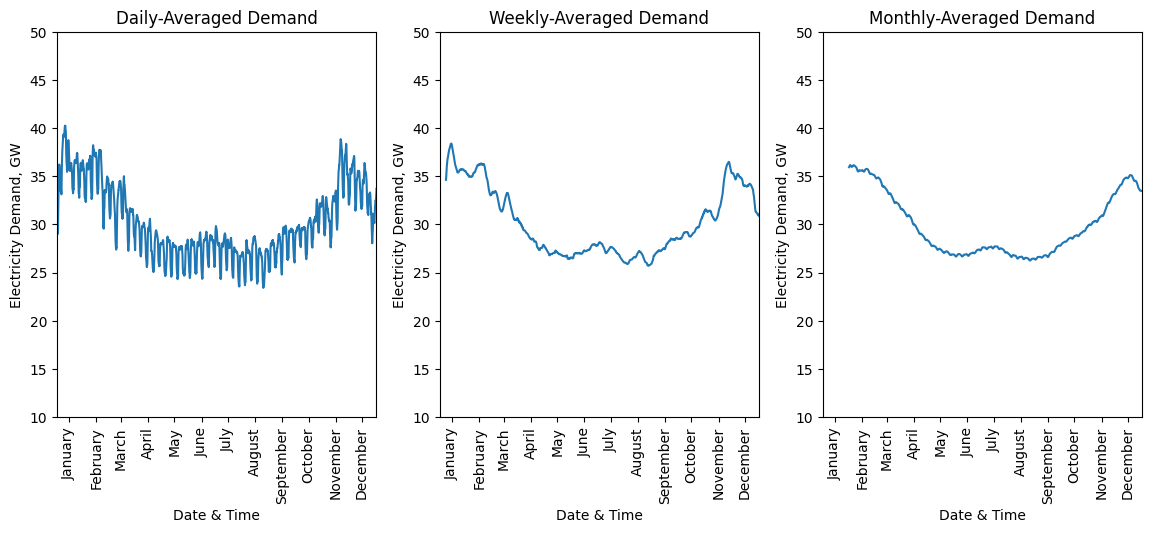

In [33]:
fig, axes = plt.subplots(ncols=3, figsize=(14,5))

axes[0].plot(electricity_demand['settlement_period_start'], electricity_demand['MA_daily'])
axes[0].set_title('Daily-Averaged Demand')
axes[0].set_xlabel('Date & Time')
axes[0].set_ylabel('Electricity Demand, GW')
axes[0].set_ylim(10,50)
axes[0].set_xlim(pd.to_datetime('2025-1-1'), pd.to_datetime('2025-12-31'))

axes[1].plot(electricity_demand['settlement_period_start'], electricity_demand['MA_weekly'])
axes[1].set_title('Weekly-Averaged Demand')
axes[1].set_xlabel('Date & Time')
axes[1].set_ylabel('Electricity Demand, GW')
axes[1].set_ylim(10,50)
axes[1].set_xlim(pd.to_datetime('2025-1-1'), pd.to_datetime('2025-12-31'))

axes[2].plot(electricity_demand['settlement_period_start'], electricity_demand['MA_monthly'])
axes[2].set_title('Monthly-Averaged Demand')
axes[2].set_xlabel('Date & Time')
axes[2].set_ylabel('Electricity Demand, GW')
axes[2].set_ylim(10,50)
axes[2].set_xlim(pd.to_datetime('2025-1-1'), pd.to_datetime('2025-12-31'))

ticks = [pd.to_datetime(f'2025-{i}-15') for i in range(1,13)]
tick_labels = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
axes[0].set_xticks(ticks)
axes[0].set_xticklabels(tick_labels, rotation=90)
axes[1].set_xticks(ticks)
axes[1].set_xticklabels(tick_labels, rotation=90)
axes[2].set_xticks(ticks)
axes[2].set_xticklabels(tick_labels, rotation=90)

plt.plot()

[]

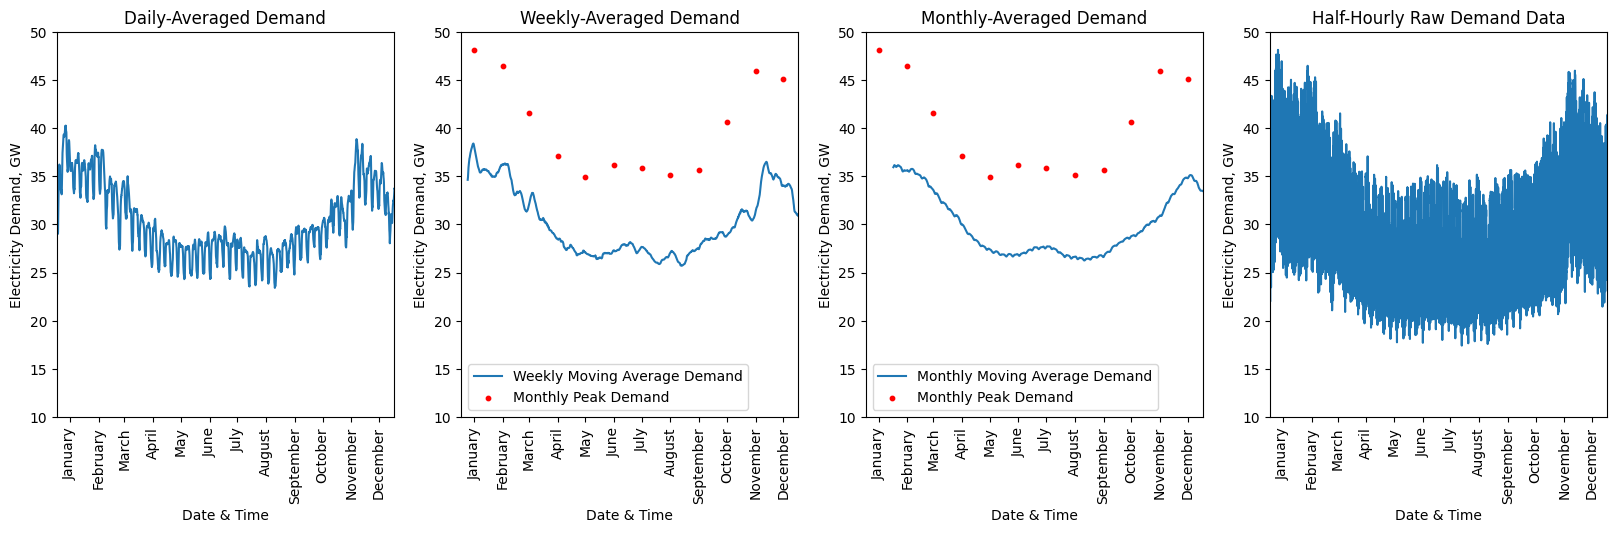

In [38]:
fig, axes = plt.subplots(ncols=4, figsize=(20,5))

axes[0].plot(electricity_demand['settlement_period_start'], electricity_demand['MA_daily'], label='Daily Moving Average Demand')
axes[0].set_title('Daily-Averaged Demand')
axes[0].set_xlabel('Date & Time')
axes[0].set_ylabel('Electricity Demand, GW')
axes[0].set_ylim(10,50)
axes[0].set_xlim(pd.to_datetime('2025-1-1'), pd.to_datetime('2025-12-31'))

axes[1].plot(electricity_demand['settlement_period_start'], electricity_demand['MA_weekly'], label='Weekly Moving Average Demand')
axes[1].set_title('Weekly-Averaged Demand')
axes[1].set_xlabel('Date & Time')
axes[1].set_ylabel('Electricity Demand, GW')
axes[1].set_ylim(10,50)
axes[1].set_xlim(pd.to_datetime('2025-1-1'), pd.to_datetime('2025-12-31'))
axes[1].scatter(peak_m_demand['month'], peak_m_demand['monthly peak'], color='red', s=10, label='Monthly Peak Demand')
axes[1].legend()

axes[2].plot(electricity_demand['settlement_period_start'], electricity_demand['MA_monthly'], label='Monthly Moving Average Demand')
axes[2].set_title('Monthly-Averaged Demand')
axes[2].set_xlabel('Date & Time')
axes[2].set_ylabel('Electricity Demand, GW')
axes[2].set_ylim(10,50)
axes[2].set_xlim(pd.to_datetime('2025-1-1'), pd.to_datetime('2025-12-31'))
axes[2].scatter(peak_m_demand['month'], peak_m_demand['monthly peak'], color='red', s=10, label='Monthly Peak Demand')
axes[2].legend()

ticks = [pd.to_datetime(f'2025-{i}-15') for i in range(1,13)]
tick_labels = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
axes[0].set_xticks(ticks)
axes[0].set_xticklabels(tick_labels, rotation=90)
axes[1].set_xticks(ticks)
axes[1].set_xticklabels(tick_labels, rotation=90)
axes[2].set_xticks(ticks)
axes[2].set_xticklabels(tick_labels, rotation=90)

axes[3].plot(electricity_demand['settlement_period_start'], electricity_demand['total_national_demand'])
axes[3].set_title('Half-Hourly Raw Demand Data')
axes[3].set_xlabel('Date & Time')
axes[3].set_ylabel('Electricity Demand, GW')
axes[3].set_ylim(10,50)
axes[3].set_xlim(pd.to_datetime('2025-1-1'), pd.to_datetime('2025-12-31'))
axes[3].set_xticks(ticks)
axes[3].set_xticklabels(tick_labels, rotation=90)
plt.savefig(r"images\2025_moving_avg_analysis.png")
plt.plot()

In [35]:
electricity_demand.head()

,settlement_period_start,total_national_demand,day_of_week,day,settlement_period,is_weekend,load_duration_curve,season,MA_daily,MA_weekly,MA_monthly
0,2025-01-01 00:00:00,26.441,2,Wednesday,1,False,48.141,Winter,NaN,NaN,NaN
1,2025-01-01 00:30:00,26.580,2,Wednesday,2,False,48.093,Winter,NaN,NaN,NaN
2,2025-01-01 01:00:00,26.622,2,Wednesday,3,False,47.659,Winter,NaN,NaN,NaN
3,2025-01-01 01:30:00,25.588,2,Wednesday,4,False,47.657,Winter,NaN,NaN,NaN
4,2025-01-01 02:00:00,24.714,2,Wednesday,5,False,47.644,Winter,NaN,NaN,NaN


In [36]:
electricity_demand.tail()

,settlement_period_start,total_national_demand,day_of_week,day,settlement_period,is_weekend,load_duration_curve,season,MA_daily,MA_weekly,MA_monthly
17515,2025-12-31 21:30:00,32.627,2,Wednesday,44,False,17.661,Winter,33.672646,31.121827,33.429702
17516,2025-12-31 22:00:00,31.408,2,Wednesday,45,False,17.655,Winter,33.661625,31.128143,33.429520
17517,2025-12-31 22:30:00,30.622,2,Wednesday,46,False,17.612,Winter,33.666167,31.135756,33.429758
17518,2025-12-31 23:00:00,29.596,2,Wednesday,47,False,17.580,Winter,33.673229,31.143301,33.430620
17519,2025-12-31 23:30:00,28.901,2,Wednesday,48,False,17.416,Winter,33.690937,31.150884,33.431439
